# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned mutual fund datasets,
understand data distributions, identify trends, and generate insights using
statistical summaries and visualizations.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"
RAW_DIR = BASE_DIR / "data" / "raw" / "Bluestock_MF_Datasets"

In [2]:
fund = pd.read_csv(RAW_DIR / "01_fund_master.csv")

nav = pd.read_csv(PROCESSED_DIR / "nav_history_clean.csv")

transactions = pd.read_csv(PROCESSED_DIR / "investor_transactions_clean.csv")

performance = pd.read_csv(PROCESSED_DIR / "scheme_performance_clean.csv")

aum = pd.read_csv(RAW_DIR / "03_aum_by_fund_house.csv")

## Dataset Overview

In [3]:
print("Fund Master:", fund.shape)
print("NAV History:", nav.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)
print("AUM:", aum.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 19)
AUM: (90, 5)


## Fund Category Distribution

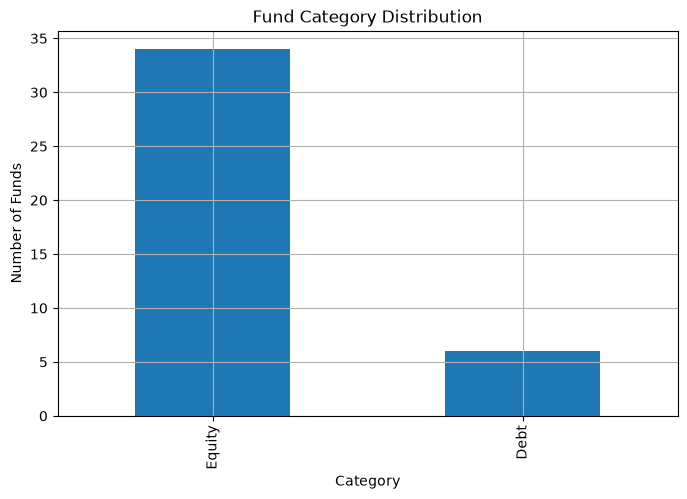

In [4]:
fund["category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Funds")
plt.grid(True)
plt.show()

### Observation

- Equity funds dominate the dataset.
- Debt funds represent a smaller portion.

## Risk Category Distribution

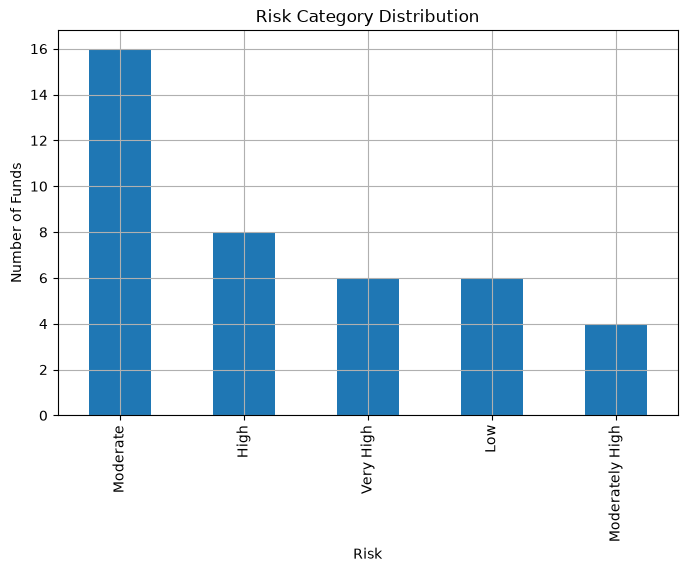

In [5]:
fund["risk_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk")
plt.ylabel("Number of Funds")
plt.grid(True)
plt.show()

### Observation

- Most mutual funds belong to the High and Very High risk categories.

## Fund House Distribution

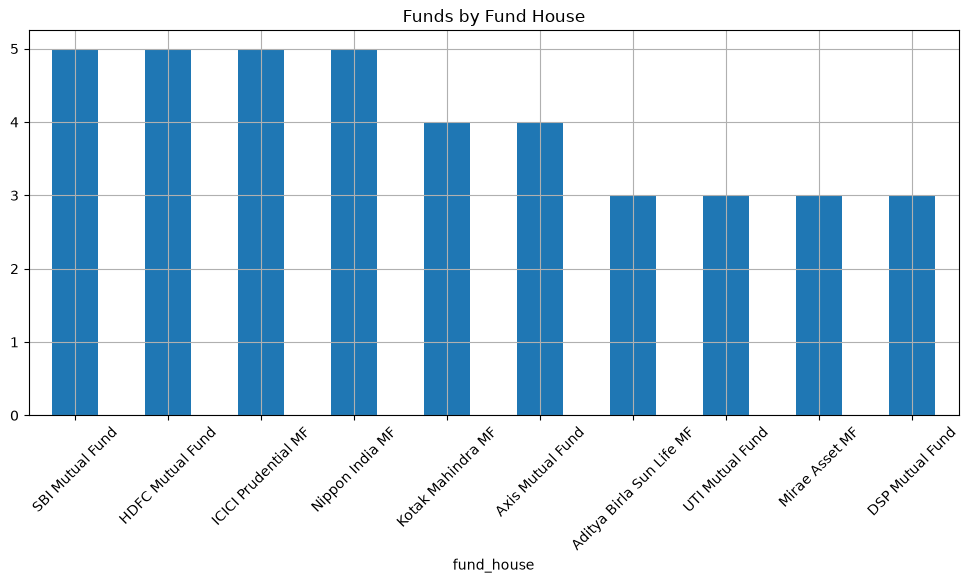

In [6]:
fund["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Funds by Fund House")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

- Multiple AMCs are represented.
- SBI, HDFC, ICICI and Axis have several schemes.

## NAV Trend

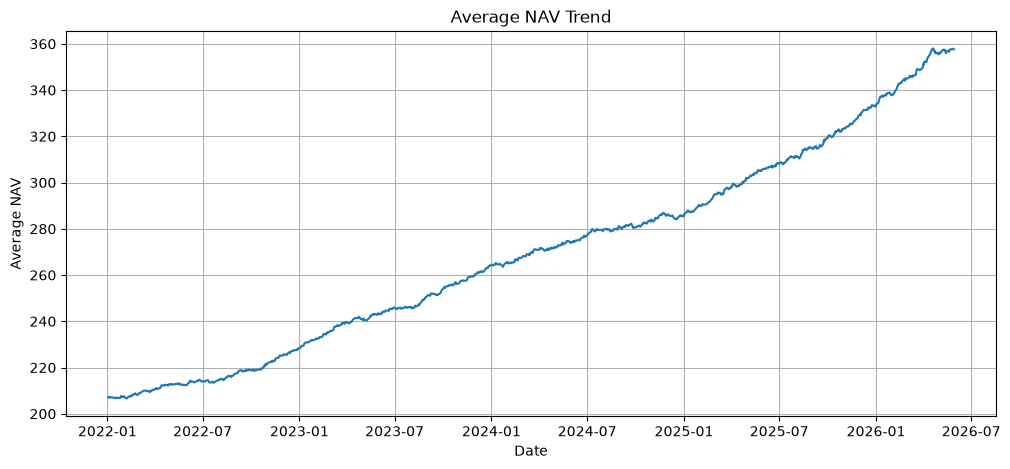

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

daily_nav = nav.groupby("date")["nav"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    daily_nav.index,
    daily_nav.values
)

plt.title("Average NAV Trend")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)

plt.show()

### Observation

- NAV values fluctuate over time.
- Overall trend indicates long-term growth.

## Transaction Types

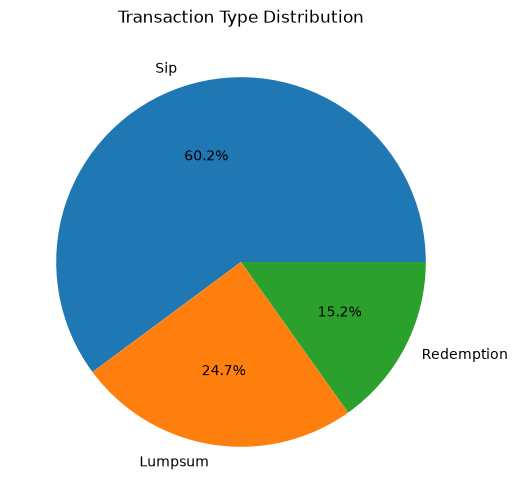

In [8]:
transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Transaction Type Distribution")
plt.show()

### Observation

- SIP transactions account for a significant portion of investor activity.

## Top Fund Houses by AUM

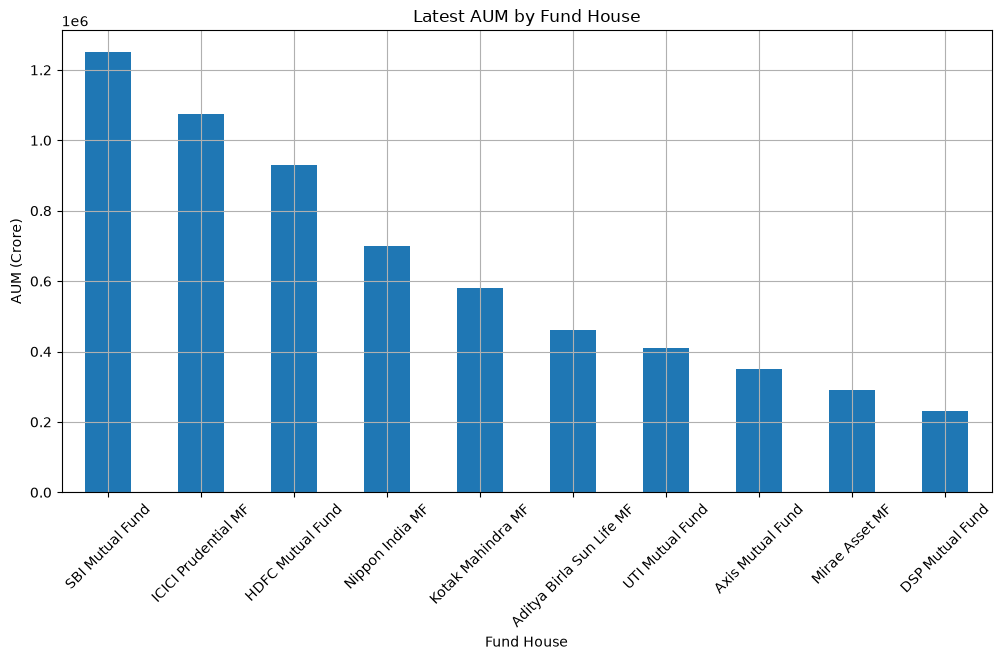

In [11]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Use the latest available date
latest_date = aum["date"].max()

latest_aum = aum[aum["date"] == latest_date]

# Plot latest AUM by fund house
latest_aum.sort_values(
    "aum_crore",
    ascending=False
).plot(
    x="fund_house",
    y="aum_crore",
    kind="bar",
    figsize=(12,6),
    legend=False
)

plt.title("Latest AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

- SBI, HDFC, ICICI Prudential, and Nippon India are among the largest fund houses by Assets Under Management (AUM).
- Larger AUM generally reflects higher investor trust and a broader asset base.
- AUM values are measured in crore rupees using the latest available reporting date.